# Imports

In [9]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

from kneed import KneeLocator, DataGenerator
from kneed import find_shape
from scipy import stats

# uncomment line below to see what datasets are available to query from the CDAWeb
a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

<sunpy.net.cdaweb.attrs.Dataset(OMNI_HRO2_1MIN: OMNI Combined, Definitive 1-minute IMF and
Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices -
J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)) object at 0x7161e8b3e490>

In [10]:
import warnings
warnings.filterwarnings("ignore")

# Functions

In [15]:
#Find DateRanges for each file needed found
def ReadDates(startDate, endDate): #ReadDatesForFileFinding
    DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
    return DateRange

#Get to date portion of the file names
def myFunc(e):
  return e.split("_")[3]

# Get the pre-downloaded data from folder
def FindData(directory, dataName, startDate, endDate): #FindDataMakeTimeSeries
    files = []
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        DateRange = ReadDates(startDate, endDate)
        for j in range(len(DateRange)):
            if filename.startswith(dataName + str(DateRange[j])):
                files.append(directory+filename)
                continue
    filesSorted = sorted(files, key=myFunc) # sort files
    dataTimeSeries = TimeSeries(filesSorted, concatenate=True)
    return dataTimeSeries

# Calculate Total Vsw
def AddTotVsw(dataTimeSeries):

    TotVsw = np.sqrt(dataTimeSeries._data["Vx"]**2 + 
                     dataTimeSeries._data["Vy"]**2 + 
                     dataTimeSeries._data["Vz"]**2)
    dataTimeSeries = dataTimeSeries.add_column("TotVsw", TotVsw)
    return dataTimeSeries

#Plot Vsw
def PlotVsw(dataTimeSeries):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["TotVsw", "flow_speed", "Vx", "Vy", "Vz"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-450,900)
    # print(dataTSFirstDates._data[""].unique())

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddBMag(dataTimeSeries):
    BMag = np.sqrt(dataTimeSeries._data["BX_GSE"]**2 + 
                   dataTimeSeries._data["BY_GSM"]**2 + 
                   dataTimeSeries._data["BZ_GSM"]**2)
    dataTimeSeries = dataTimeSeries.add_column("BMag", BMag)
    return dataTimeSeries

#Plot B
def PlotB(dataTimeSeries):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["BMag", "BX_GSE", "BY_GSM", "BZ_GSM"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-40,90)
    # print(dataTSFirstDates._data[""].unique())

# Dotted plots
def PlotVswDotted(dataTimeSeries):
    fig, ax  = plt.subplots(5, sharex=True, figsize=(10, 10))
    # total OMNI speed
    dataTimeSeries._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
    ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
    # flow speed
    dataTimeSeries._data["flow_speed"].plot(ax=ax[1], marker='.', ls='', ms=1)
    ax[1].set_ylabel("Flow speed (km/s)")
    # components of OMNI speed, Vx
    dataTimeSeries._data["Vx"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
    ax[2].set_ylabel("Vx V$_{SW}$ (km/s)")
    # components of OMNI speed, Vy
    dataTimeSeries._data["Vy"].plot(ax=ax[3], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
    ax[3].set_ylabel("Vy V$_{SW}$ (km/s)")
    # components of OMNI speed, Vz
    dataTimeSeries._data["Vz"].plot(ax=ax[4], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar OMNI is mostly radial/along the Parker spiral
    ax[4].set_ylabel("Vz V$_{SW}$ (km/s)")

    for aa in ax:
        aa.legend(loc="upper left")
        # aa.axvline("2022-01-29 00:00", color='k')
        # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
        # aa.set_ylim(-400,400)

    # ax[4].set_xlabel("Time")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.02)

# Plot histograms all together
def PlotHistTogether(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "OMNI " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)
        plt.title("Solar OMNI " + VarsToPlot[i])
        plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
        plt.legend(fontsize=Legend)
        plt.show()

#Plot histograms separately
def PlotHistSeparate(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)): # For each variable
        LowerBounds = [] # set lower bounds array to 0
        UpperBounds = [] # set upper bounds array to 0
        fig, axs = plt.subplots(len(VarsToPlot),1, figsize=FigSize, sharex=True)
        fig.subplots_adjust(hspace=0)
        for j in range(len(dataTimeSerieses)): # For each daterange
            axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "OMNI " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)
            #Mean
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].mean()))
            #Median
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].median()))
            #Standard deviation
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].std()), alpha = 0)

            axs[j].legend(loc = LegLoc, fontsize = Legend)
                # axs[1].legend(loc = LegLoc, fontsize = Legend)
                # axs[2].legend(loc = LegLoc, fontsize = Legend)
                # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
            LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
        
        plt.suptitle("Solar OMNI "+ VarsToPlot[i] + ", omni_hro2_1min", fontsize = SupTitle)
        fig.supxlabel(VarsToPlot[i] + ", " + str(Units[i]))

        plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        plt.savefig("Plots/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + ".png")
        # plt.show()

# Plot CDF
def PlotCDF(dataTimeSerieses, VarsToPlot):
    # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
    # fig.subplots_adjust(hspace=0)
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            sns.ecdfplot(dataTimeSerieses[j]._data[VarsToPlot[i]], label="OMNI " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
        plt.xlabel(VarsToPlot[i] + ", " + Units[i])
        plt.ylabel('Cumulative probability')
        plt.ylim(yLim)
        plt.legend(fontsize=Legend)
        plt.grid(True)
        plt.savefig("Plots/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
        plt.show()

## Plot DQQs
# Calculate quantiles
def get_quantiles(
    x: pl.Series,
    y: pl.Series,
    size: int = 500, # 500 data points to calculate (default)
    p_range: Tuple[float, float] = (0.0001, 0.9999),) -> Tuple[NDArray, NDArray]: # p_range default set to values used in Tindale and Chapman 2017 to recreate their plots

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy()) # Sort data
    y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy()) # Sort data

    probabilities = np.linspace(*p_range, size) # make linspace of probabilities in range

    x_quantiles = np.quantile(x_sorted, probabilities) # calculate the quantiles
    y_quantiles = np.quantile(y_sorted, probabilities) # calculate the quantiles

    return x_quantiles, y_quantiles

## Simple FindKnee function without breakpoint finding
# def FindKnee(x, y):
#     direction, curve = find_shape(x, y)
#     kl = KneeLocator(x, y, curve=curve, direction=direction)
#     xOfKnee = kl.knee
#     yOfKnee = kl.knee_y
#     return xOfKnee, yOfKnee

# FindKnee function with breakpoint finding
def FindQuantOfKnee(x, y):
    direction, curve = find_shape(x, y)
    xlen = len(x)
    ylen = len(y)
    print(xlen, ylen)
    # kl = KneeLocator(x[int(xlen/2):-1], y[int(ylen/2):-1], curve=curve, direction=direction)
    kl = KneeLocator(x, y, curve=curve, direction=direction)
    xOfKnee = kl.knee
    yOfKnee = kl.knee_y
    print(xOfKnee, yOfKnee)
    
    XRes = stats.ecdf(x)#(xOfKnee)
    YRes = stats.ecdf(y)
    # print(Strawb.cdf.quantiles[4000])
    FindXidx = np.where(XRes.cdf.quantiles == xOfKnee)
    FindYidx = np.where(YRes.cdf.quantiles == yOfKnee)
    print(FindXidx, FindYidx)

    FindXidx = FindXidx[0][0]
    FindYidx = FindYidx[0][0]

    if FindXidx == FindYidx:
        ProbValue = XRes.cdf.probabilities[FindXidx]
        print(XRes.cdf.probabilities[FindXidx])
        print(YRes.cdf.probabilities[FindYidx])

    else:
        print("Indexes don't match")
        print(FindXidx, FindYidx)
        print(XRes.cdf.quantiles[FindXidx])
        print(YRes.cdf.quantiles[FindYidx])
        print("XRes -1")
        print(XRes.cdf.quantiles[FindXidx-1])
        print("YRes -1")
        print(YRes.cdf.quantiles[FindYidx-1])
        # ProbValue = XRes.cdf.probabilities[FindXidx]
        # ProbValue = YRes.cdf.probabilities[FindYidx]
        ProbValue = np.nan

    quantOfKnee = ProbValue
    return xOfKnee, yOfKnee, quantOfKnee

#Plot DQQ graphs with qs
def PlotDQQ(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])
            xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
            plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

            xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

            if np.isnan(quantOfKnee):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x
        plt.plot(x, y, color="grey")
        plt.title("T&C 2017 Fig 4aiii)")
        plt.legend(loc="lower right", fontsize = Legend)
        plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
        plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
        plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.savefig("DQQ.png")

        plt.show()

# Omni data

## Date ranges

In [16]:
Start  = "1995-01-01 00:00"
End  = "2013-12-31 23:59"  # download rest of 2014

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)



['19950101', '19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101']


19950101 19960101
19960101 19970101
19970101 19980101
19980101 19990101
19990101 20000101
20000101 20010101
20010101 20020101
20020101 20030101
20030101 20040101
20040101 20050101
20050101 20060101
20060101 20070101
20070101 20080101
20080101 20090101
20090101 20100101
20100101 20110101
20110101 20120101
20120101 20130101
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			Unknown
Channel(s):			AE_INDEX<br>AL_INDEX<br>ASY_D<br>ASY_H<br>AU_INDEX<br>BSN_x<br>BSN_y<br>BSN_z<br>BX_GSE<br>BY_GSE<br>BY_GSM<br>BZ_GSE<br>BZ_GSM<br>Beta<br>Day<br>E<br>F<br>HR<br>IMF<br>IMF_PTS<br>Mach_num<br>Mgs_mach_num<br>Minute<br>NaNp_Ratio<br>PLS<br>PLS_PTS<br>Pressure<br>RMS_SD_B<br>RMS_SD_fld_vec<br>RMS_Timeshift<br>RMS_phase<br>SYM_D<br>SYM_H<br>T<br>Time_btwn_obs<br>Timeshift<br>Vx<br>Vy<br>Vz<br>YR<br>flow_speed<br>percent_interp<br>proton_density<br>x<br>y<br>z<br>TotVsw<br>BMag
Start Date:			1995-12-01 00:00:00
End Date:			1996-01-31 23:59:00
Center Date:			1995-12-31 23:59:30
Res

IndexError: index 4 is out of bounds for axis 0 with size 4

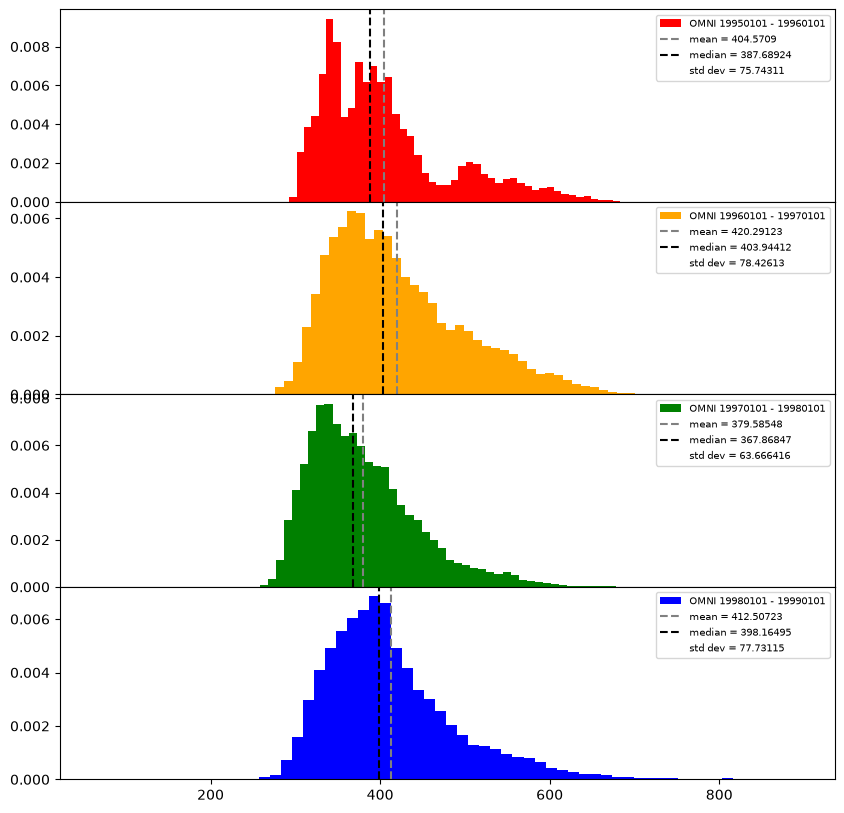

In [17]:
directory = "./omniData/"
dataName = "omni_hro2_1min_"
Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
FigSize = (10,10)
LegLoc = 'upper right'
SpaceLR = [100, 5, 5, 5, 5]
Colours = ["red", "orange", "green", "blue"]

dataTimeSerieses = []
StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i+1]
    print(StartDate, EndDate)
    DateRange = ReadDates(StartDate, EndDate) # get date range
    dataTS = FindData(directory, dataName, StartDate, EndDate) # find data
    dataTS = AddTotVsw(dataTS) # add totvsw
    dataTS = AddBMag(dataTS) # add bmag
    dataTimeSerieses.append(dataTS)
    StartAndEnd.append([StartDate, EndDate])

print(dataTimeSerieses)

# Histogram formatting - Separate
    
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT"]#, "nT", "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]

PlotHistSeparate(dataTimeSerieses, Plotting)


# #Find DateRanges for each file needed found
# def ReadDates(startDate, endDate): #ReadDatesForFileFinding
#     DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
#     return DateRange

# # Cycle 23 Min # 1 Dec 95 - 30 Nov 96 as Cycle 23 min
# startDateC23Min = "1995-12-01 00:00"
# endDateC23Min = "1996-11-30 23:59"

# # Cycle 23 Max # 1 Oct 99 - 30 Sept 00 as Cycle 23 max
# startDateC23Max = "1999-10-01 00:00"
# endDateC23Max = "2000-09-30 23:59"

# # Cycle 24 Min # 1 Aug 07 - 31 July 08 as Cycle 24 min
# startDateC24Min = "2007-08-01 00:00"
# endDateC24Min = "2008-07-31 23:59"

# # Cycle 24 Max # 1 Nov 13 - 31 Oct 14 as Cycle 24 max
# startDateC24Max = "2013-11-01 00:00"
# endDateC24Max = "2014-10-31 23:59"

# DateRangeC23Min = ReadDates(startDateC23Min, endDateC23Min)
# print(DateRangeC23Min)
# DateRangeC23Max = ReadDates(startDateC23Max, endDateC23Max)
# print(DateRangeC23Max)
# DateRangeC24Min = ReadDates(startDateC24Min, endDateC24Min)
# print(DateRangeC24Min)
# DateRangeC24Max = ReadDates(startDateC24Max, endDateC24Max)
# print(DateRangeC24Max)

## Find data in files

## Histograms

### All together histograms

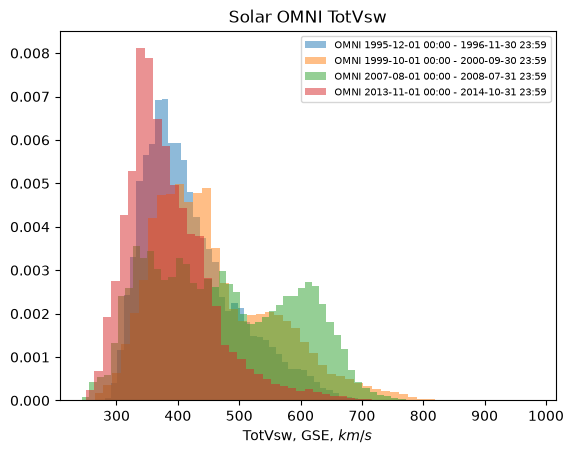

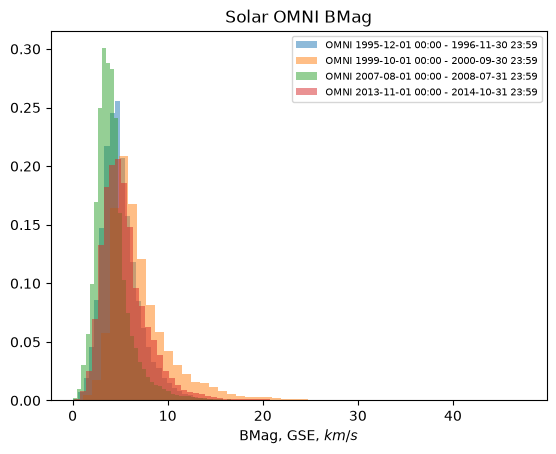

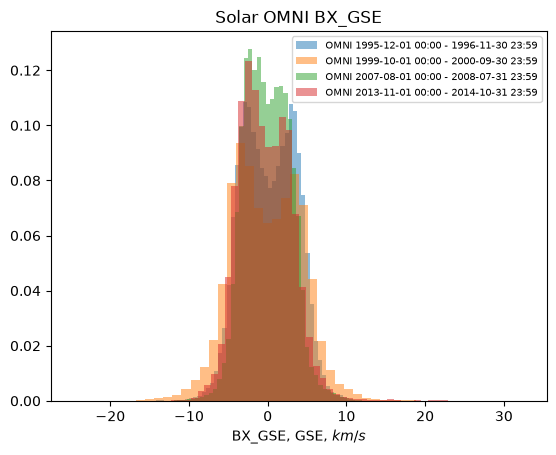

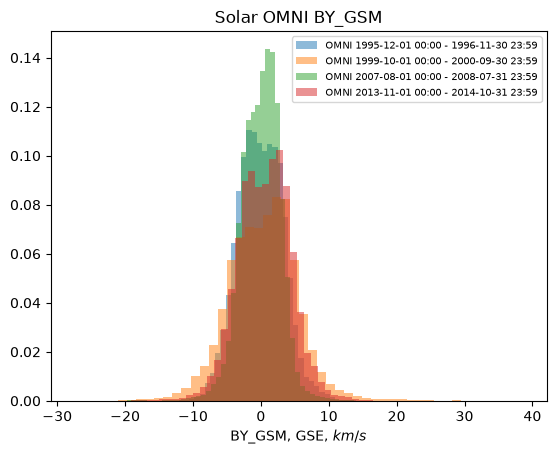

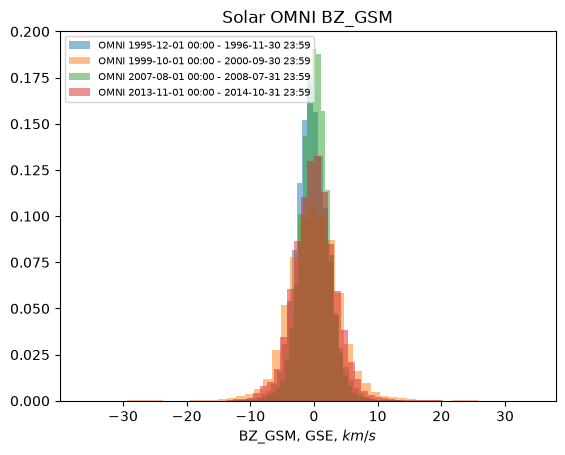

In [ ]:
# Histogram formatting - all together
Bin = 50
Alpha = 0.5
Legend = 7.5
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]
dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC24Max, endDateC24Max]]

PlotHistTogether(dataTimeSerieses, Plotting)

### Separate histograms

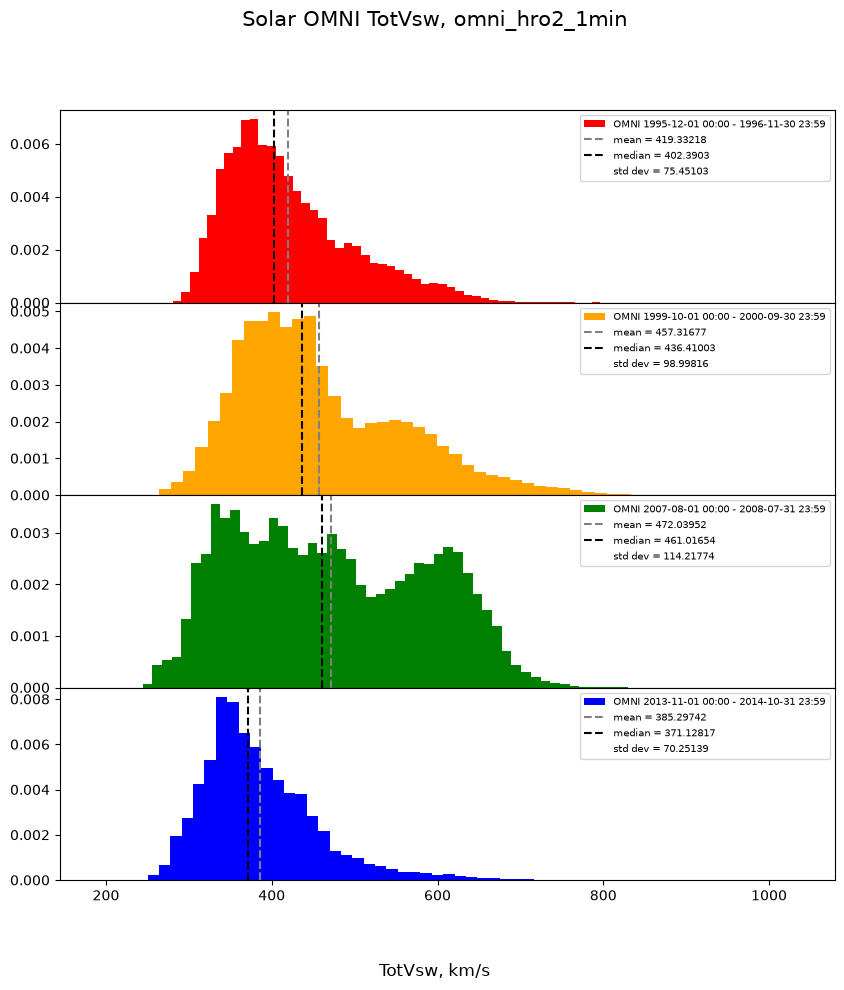

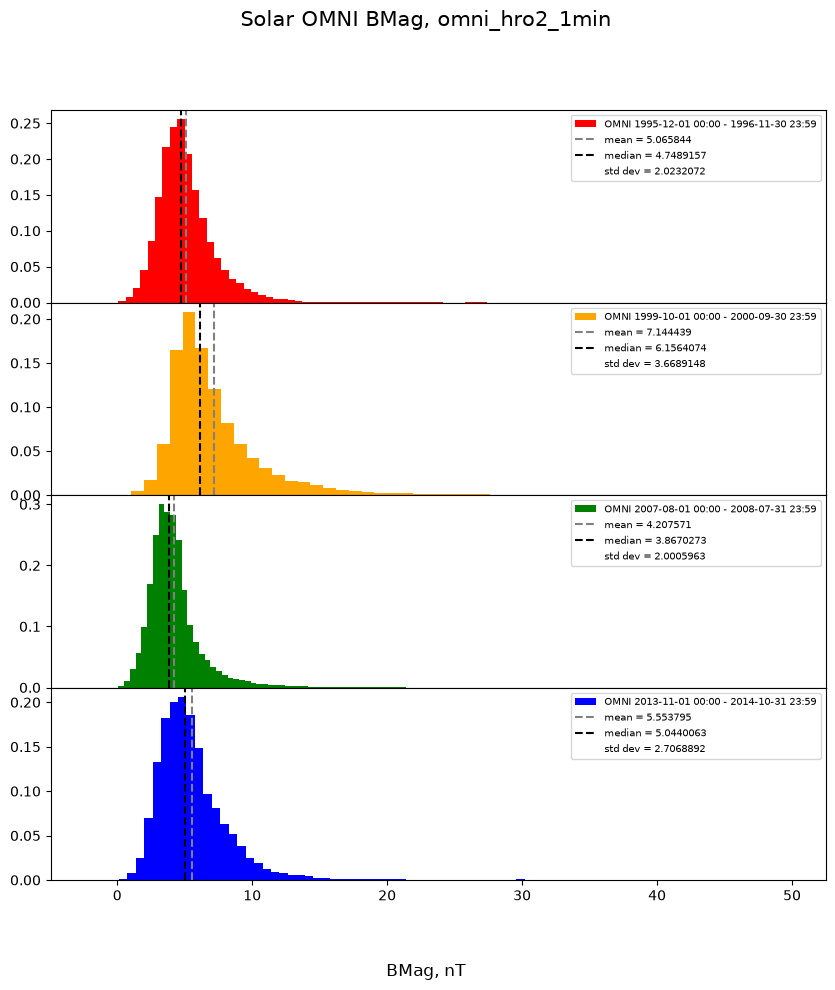

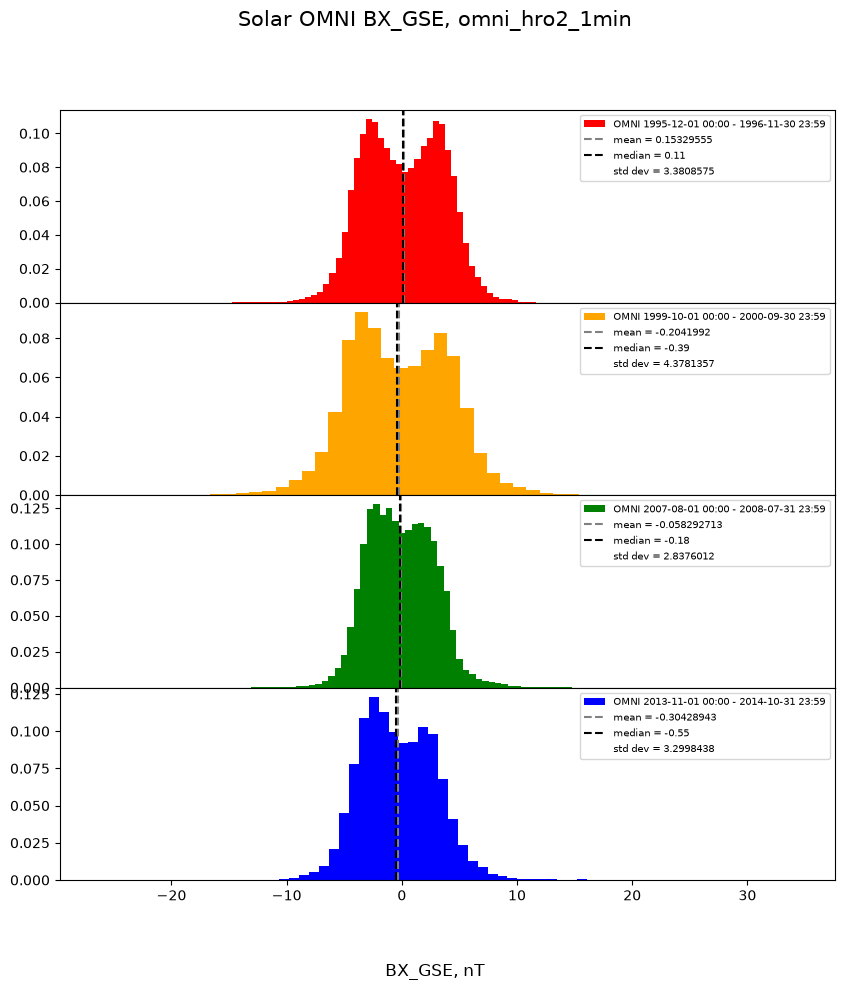

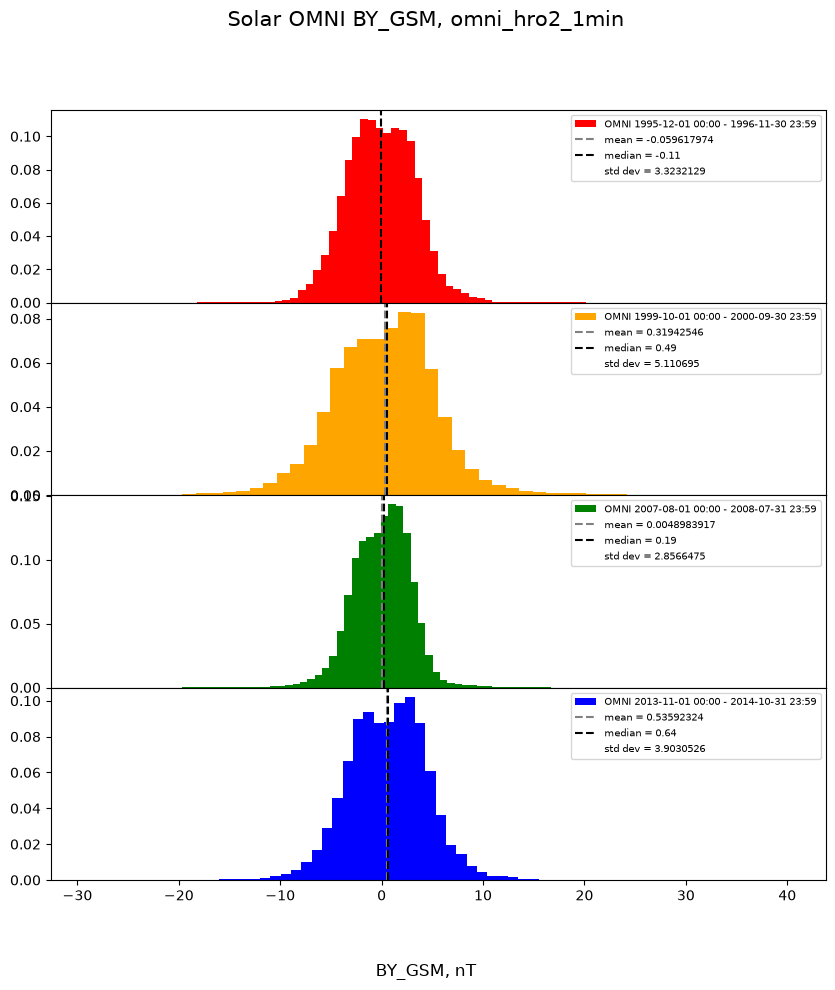

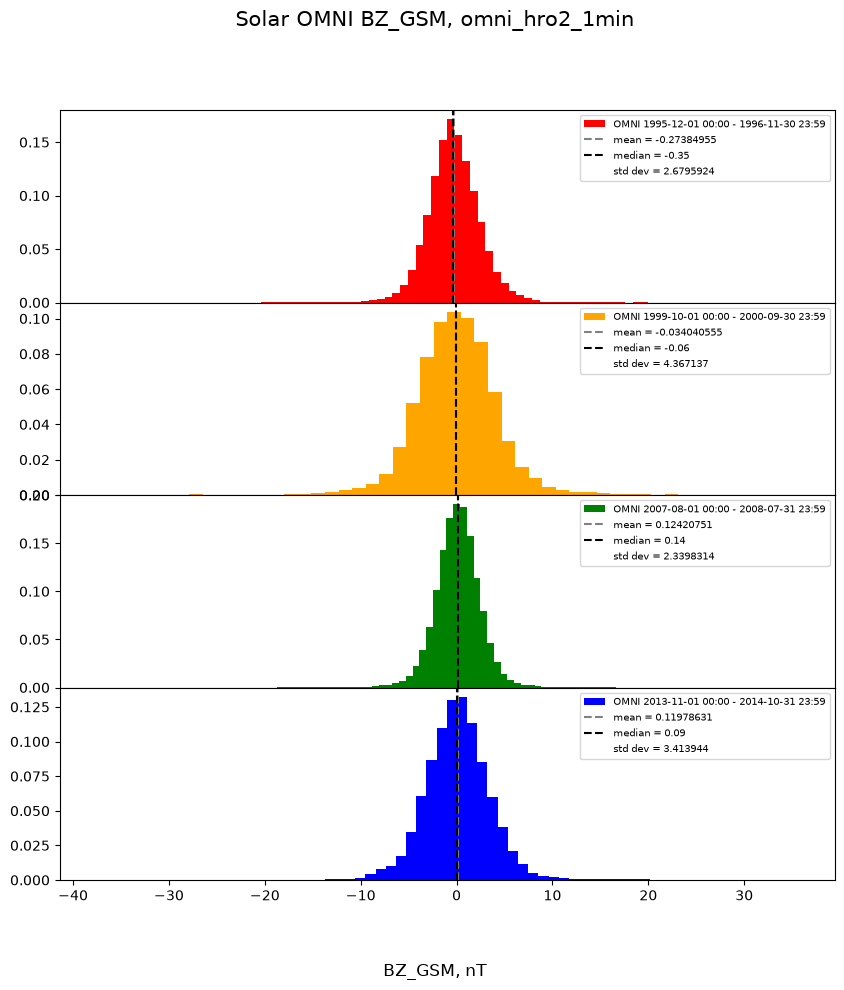

In [ ]:
# Histogram formatting - Separate
Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
FigSize = (10,10)
LegLoc = 'upper right'
SpaceLR = [100, 5, 5, 5, 5]
Colours = ["red", "orange", "green", "blue"]
dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT", "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]

PlotHistSeparate(dataTimeSerieses, Plotting)

## CDFs

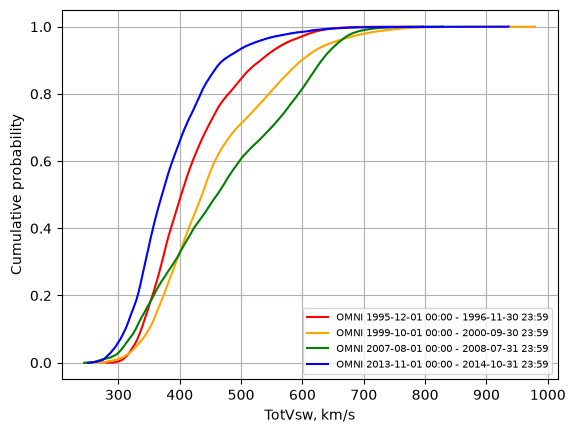

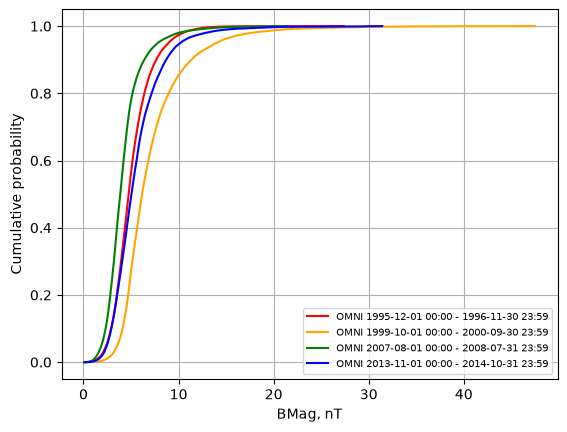

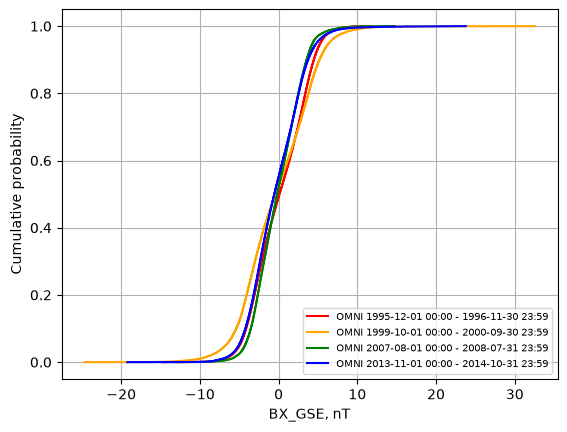

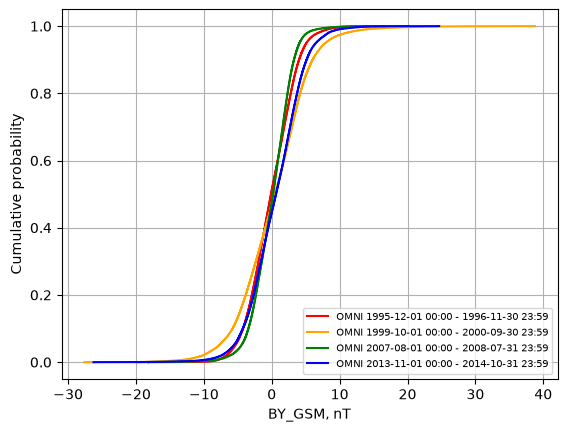

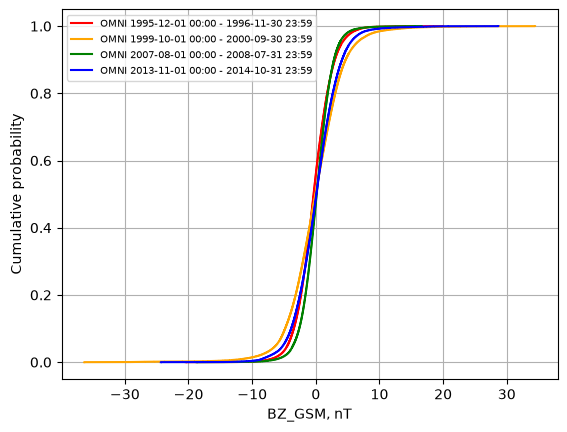

In [79]:
# CDF Formatting
yLim = [-0.05,1.05]
Legend = 7.5
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]
Unit = ["km/s", "nT", "nT", "nT", "nT", "nT"]

PlotCDF(dataTimeSerieses, Plotting)

## Plotting DQQ and finding q values

### Plotting

5000 5000
286.03647461547854 267.81975830688475
(array([0]),) (array([0]),)
0.0002
0.0002
5000 5000
600.5170152282715 438.5252990722656
(array([4087]),) (array([4087]),)
0.8176
0.8176


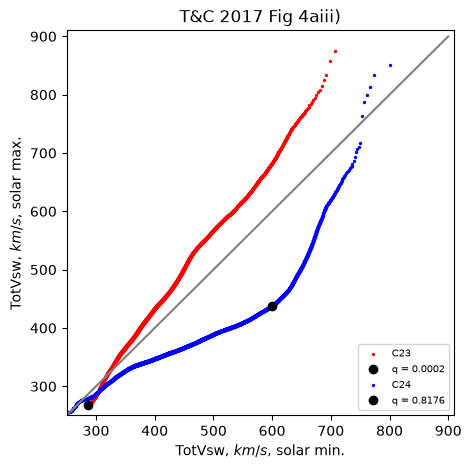

5000 5000
5.062025547027588 6.670309435367584
(array([2892]),) (array([2892]),)
0.5786
0.5786
5000 5000
3.274451658916473 4.188185691833496
(array([1618]),) (array([1618]),)
0.3238
0.3238


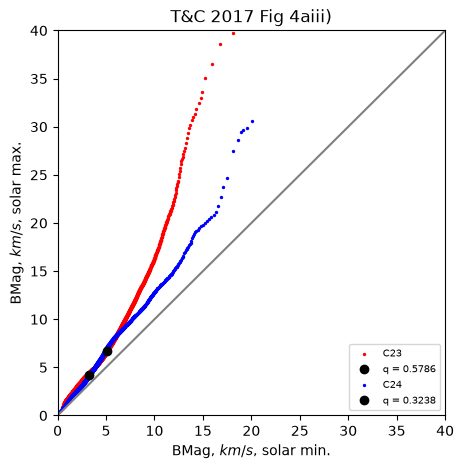

5000 5000
8.566005984306388 12.380000114440918
(array([1435]),) (array([1801]),)
Indexes don't match
1435 1801
8.566005984306388
12.380000114440918
XRes -1
8.470000267028809
YRes -1
12.220000267028809
---------------------------
Error finding breakpoints q
---------------------------
5000 5000
12.90999984741211 22.53694218349484
(array([1279]),) (array([1438]),)
Indexes don't match
1279 1438
12.90999984741211
22.53694218349484
XRes -1
11.399999618530273
YRes -1
21.899999618530273
---------------------------
Error finding breakpoints q
---------------------------


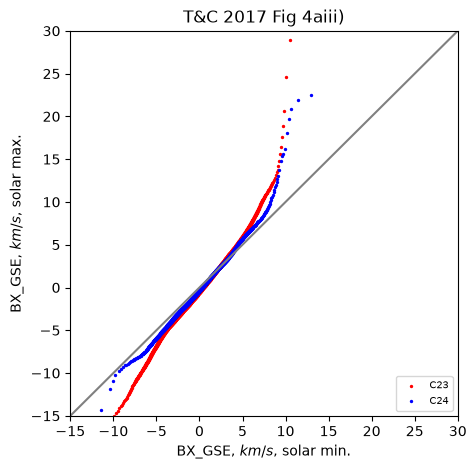

In [80]:
Plotting = ["TotVsw", "BMag", "BX_GSE"]#, "BY_GSM", "BZ_GSM"]
Lims = [[250, 910], [0, 40], [-15, 30]]#, [-15, 30], [-15, 30]]
# Breakpoints = [ [[ 0.9960, 0.9995], [ 0.8660, 0.9980]], [[ 0.9990, 0.9750], [ 0.9990, 0.9970]], [[ 0.9980, 0.1100], [ 0.9980, 0.1100]]]
dataTimeSeriesToCompare = [ [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max], [dataTSFirstDatesC24Min, dataTSFirstDatesC24Max] ]
# dataTimeSeriesToCompare = [ [dataTSFirstDatesC24Min, dataTSFirstDatesC24Max] ]
PlotLabels = ["C23", "C24"]
Color = ["red", "blue"]

PlotDQQ(dataTimeSeriesToCompare, Plotting, Breakpoints)

# Separated Fast and Slow Wind

Epoch
1995-12-01 00:00:00    401.709991
1995-12-01 00:01:00    397.911652
1995-12-01 00:02:00    396.365509
1995-12-01 00:03:00    395.029236
1995-12-01 00:04:00    395.765076
                          ...    
1996-11-30 23:55:00    300.506317
1996-11-30 23:56:00    298.219421
1996-11-30 23:57:00    298.660461
1996-11-30 23:58:00    299.752869
1996-11-30 23:59:00    299.293091
Name: TotVsw, Length: 527040, dtype: float32


KeyError: 0

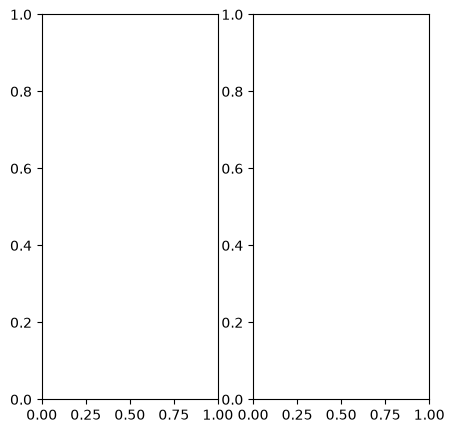

In [105]:
# print(dataTimeSeriesToCompare)

#Plot DQQ graphs with qs
def PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, SplitValue):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(1,2, figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])

            print(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])

            # s = pl.Series("a", [1, 2, 3])
            MaskingBelow = []
            MaskingAbove = []
            for m in range(len(dataTimeSeriesPS1)):
                if dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]][m] < SplitValue:
                    MaskingBelow.append(True)
                    MaskingAbove.append(False)
                else:
                    MaskingBelow.append(False)
                    MaskingAbove.append(True)

            maskBelow = pl.Series("", MaskingBelow)
            maskAbove = pl.Series("", MaskingAbove)

            dataTimeSeriesPS1Below = dataTimeSeriesPS1.filter(maskBelow)
            dataTimeSeriesPS1Above = dataTimeSeriesPS1.filter(maskAbove)  

            xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
            axs[0].scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
            xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
            axs[1].scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])

            xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
            xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)

            if np.isnan(quantOfKneeBelow):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black", label = "q = " + str(quantOfKneeBelow))
                # plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black")

            if np.isnan(quantOfKneeAbove):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black", label = "q = " + str(quantOfKneeAbove))
                # plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black")


            # xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
            # plt.scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
            # xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
            # plt.scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])
            
            # xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
            # xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)
            
            # if np.isnan(quantOfKnee):
            #     print("---------------------------")
            #     print("Error finding breakpoints q")
            #     print("---------------------------")
            # else:
            #     plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            #     # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x

        for aa in ax:
            aa.plot(x, y, color="grey")
            aa.legend(loc="lower right", fontsize = Legend)
            aa.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
            aa.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
            aa.set_xlim(Lims[i])
            aa.set_ylim(Lims[i])
        
        ax[0].savefig("DQQBelow.png")
        ax[1].savefig("DQQAbove.png")

        plt.show()

        # C23
        # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
        # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, Plotting, Breakpoints, 450)

# Archived code

In [82]:
# import cdflib
# cdf_file = cdflib.CDF('wi_k0_swe_19951201_v02.cdf')
# cdf_file.cdf_info()
# print(cdf_file.varget)

# import pandas as pd
# cdf_fileDF = pd.DataFrame(cdf_file)
# print(cdf_fileDF)

# import warnings
# warnings.filterwarnings("ignore")
# WIND = TimeSeries(cdf_fileDF)


In [83]:
# import cdflib

# # CDFmerge
# # One file
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file.cdf_info()

# # #  For multiple files
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file2 = cdflib.CDF("wi_k0_swe_19951202_v02.cdf")

# directory = "."

# for file in os.listdir(directory):
#     filename = os.fsdecode(file)
#     if filename.endswith(".cdf") or filename.endswith(".py"): 
#         print(os.path.join(directory, filename))
#         FileAsCDF = cdflib.xarray.cdf_to_xarray(filename, to_datetime=True, to_unixtime=False, fillval_to_nan=False)
#         FileAsDF = FileAsCDF.to_dataframe


#         continue
#     else:
#         continue


# # X1 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951201_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)
# # X2 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951202_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)

# # # import xr.DataArray

# # giveMe = X1.to_dataframe

# # print(giveMe)


In [84]:

# # print(cdf_file.cdf_info)
# VswComponents = cdf_file.varget("V_GSM")#, startrec=0, endrec=150)
# print(VswComponents[1][2])

# TotVsw = []
# for a in range(len(VswComponents)):
#     # Calculated = )
#     # print(Calculated)
#     TotVsw.append( np.sqrt(VswComponents[a][0]**2 + VswComponents[a][1]**2 + VswComponents[a][2]**2) )

# print(len(TotVsw))
# # print(TotVsw)

# Time = cdf_file.varget("Epoch")#, startrec=0, endrec=150)
# # print(Time[1])

# DateTime = []
# for b in range(len(Time)):
#     DateTime.append (((Time[b]/1000)/3600))# /1000 milliseconds to seconds, /3600 to hours, /24 to days
# print(len(DateTime))
# # print(DateTime[0])


In [85]:
# fig, ax = plt.subplots()
# plt.plot(DateTime, TotVsw)
# # plt.legend(loc="upper right")
# # plt.ylim(-450,900)

In [86]:
# # import matplotlib.pyplot as plt
# # import numpy as np

# # create some randomly ddistributed data:
# data = TotVsw

# # sort the data:
# data_sorted = np.sort(data)

# # calculate the proportional values of samples
# p = 1. * np.arange(len(data)) / (len(data) - 1)

# # plot the sorted data:
# fig = plt.figure()
# ax1 = fig.add_subplot(121)
# ax1.plot(p, data_sorted)
# ax1.set_xlabel('$p$')
# ax1.set_ylabel('$x$')

# ax2 = fig.add_subplot(122)
# ax2.plot(data_sorted, p)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$p$')
# plt.tight_layout()

In [87]:
# fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))



# # total wind speed
# WIND._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
# ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
# # plt.axhline(400, ls="dashed")

# # components of wind speed
# WIND._data["V_GSM_0"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
# ax[1].set_ylabel("V_GSM_0 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_1"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
# ax[2].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_2"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar wind is mostly radial/along the Parker spiral
# ax[3].set_ylabel("V_GSM_2 V$_{SW}$ (km/s)")



# for aa in ax:
#     aa.legend(loc="upper left")
#     # aa.axvline("2022-01-29 00:00", color='k')
#     # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
#     # aa.set_ylim(-400,400)

# # ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
# # ax[4].set_xlabel("Time")
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.02)

In [88]:
# # C23
# data_sortedPLSeriesXC23 = pl.Series(OMNIC23Min._data["TotVsw"]) # make data into a polar series
# data_sortedPLSeriesYC23 = pl.Series(OMNIC23Max._data["TotVsw"])

# xQuantC23, yQuantC23 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 5000, p_range=(0.0001, 0.9999))
# xQ09995, yQ09995 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9995, 0.9995))
# print("q = 0.9995 C23")
# print(xQ09995, yQ09995)
# xQ09960, yQ09960 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9960, 0.9960))
# print("q = 0.9960 C23")
# print(xQ09960, yQ09960)

# # C24
# data_sortedPLSeriesXC24 = pl.Series(OMNIC24Min._data["TotVsw"]) # make data into a polar series
# data_sortedPLSeriesYC24 = pl.Series(OMNIC24Max._data["TotVsw"])

# xQuantC24, yQuantC24 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 5000, p_range=(0.0001, 0.9999))
# xQ09980, yQ09980 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.9980, 0.9980))
# print("q = 0.9980 C24")
# print(xQ09980, yQ09980)
# xQ08660, yQ08660 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.8660, 0.8660))
# print("q = 0.8660 C24")
# print(xQ08660, yQ08660)

# fig, ax  = plt.subplots(figsize=(5, 5))
# #C23
# plt.scatter(xQuantC23, yQuantC23 , color="red", s=2, label = "C23")
# plt.plot(xQ09980, yQ09980, "o", color="black")
# plt.plot(xQ08660, yQ08660, "o", color="black")

# #C24
# plt.scatter(xQuantC24, yQuantC24, color="blue", s=2, label = "C24")
# plt.plot(xQ09995, yQ09995, "o", color="black")
# plt.plot(xQ09960, yQ09960, "o", color="black")

# x = np.linspace(250, 900, 30)
# y = x
# plt.plot(x, y, color="grey")
# plt.title("T&C 2017 Fig 4aiii)")
# plt.legend(loc="lower right")
# plt.xlabel(r"TotVsw, $km/s$, solar min.")
# plt.ylabel(r"TotVsw, $km/s$, solar max.")
# plt.xlim(250,900)
# plt.ylim(250,900)
# plt.show()

In [89]:
# Histogram formatting settings
# Bin = 50
# SupTitle = 15
# Legend = 10
# FigSize = (10,10)
# SpaceLRVsw = 100
# SpaceLRB = 5
# LegLoc = 'upper right'
# Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]

# #C23 Min
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Solar OMNI Velocity, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"TotVsw, GSE, $km/s$")
# # axs[1].set_xlabel(r"TotVsw, GSE, $km/s$")
# # axs[2].set_xlabel(r"TotVsw, GSE, $km/s$")
# axs[3].set_xlabel(r"TotVsw, GSE, $km/s$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["TotVsw"].mean()))
# axs[1].axvline(OMNIC23Max._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["TotVsw"].mean()))
# axs[2].axvline(OMNIC24Min._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["TotVsw"].mean()))
# axs[3].axvline(OMNIC24Max._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["TotVsw"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["TotVsw"].median()))
# axs[1].axvline(OMNIC23Max._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["TotVsw"].median()))
# axs[2].axvline(OMNIC24Min._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["TotVsw"].median()))
# axs[3].axvline(OMNIC24Max._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["TotVsw"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["TotVsw"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["TotVsw"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["TotVsw"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["TotVsw"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC23Min._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC23Max._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC23Max._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC24Min._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC24Min._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC24Max._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC24Max._data["TotVsw"].values))

# plt.xlim(min(LowerBounds) - SpaceLRVsw, max(UpperBounds) + SpaceLRVsw)
# plt.savefig("Plots/" +"TotVsw_GSE.png")
# plt.show()


# #C23 Max
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BX_GSE"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BX_GSE"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BX_GSE"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BX_GSE"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, Bx GSE/GSM, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"Bx, GSE/GSM, $nT$")
# # axs[1].set_xlabel(r"Bx, GSE/GSM, $nT$")
# # axs[2].set_xlabel(r"Bx, GSE/GSM, $nT$")
# axs[3].set_xlabel(r"Bx, GSE/GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BX_GSE"].mean()))
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BX_GSE"].mean()))
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BX_GSE"].mean()))
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BX_GSE"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BX_GSE"].median()))
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BX_GSE"].median()))
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BX_GSE"].median()))
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BX_GSE"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BX_GSE"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BX_GSE"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BX_GSE"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BX_GSE"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC23Min._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC23Max._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC23Max._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC24Min._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC24Min._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC24Max._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC24Max._data["BX_GSE"].values))


# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds) + SpaceLRB)
# plt.savefig("Plots/" + "MagFieldX_GSE_GSM.png")
# plt.show()


# #C24 Min
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BY_GSM"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BY_GSM"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BY_GSM"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BY_GSM"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, By, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"By, GSM, $nT$")
# # axs[1].set_xlabel(r"By, GSM, $nT$")
# # axs[2].set_xlabel(r"By, GSM, $nT$")
# axs[3].set_xlabel(r"By, GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BY_GSM"].mean()))
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BY_GSM"].mean()))
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BY_GSM"].mean()))
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BY_GSM"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BY_GSM"].median()))
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BY_GSM"].median()))
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BY_GSM"].median()))
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BY_GSM"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BY_GSM"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BY_GSM"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BY_GSM"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BY_GSM"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC23Min._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC23Max._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC23Max._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC24Min._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC24Min._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC24Max._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC24Max._data["BY_GSM"].values))

# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds)+ SpaceLRB)
# plt.savefig("Plots/" +"MagFieldY_GSM.png")
# plt.show()


# #C24 Max
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BZ_GSM"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BZ_GSM"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BZ_GSM"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BZ_GSM"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, Bz, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"Bz, GSM, $nT$")
# # axs[1].set_xlabel(r"Bz, GSM, $nT$")
# # axs[2].set_xlabel(r"Bz, GSM, $nT$")
# axs[3].set_xlabel(r"Bz, GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BZ_GSM"].mean()))
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BZ_GSM"].mean()))
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BZ_GSM"].mean()))
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BZ_GSM"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BZ_GSM"].median()))
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BZ_GSM"].median()))
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BZ_GSM"].median()))
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BZ_GSM"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BZ_GSM"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BZ_GSM"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BZ_GSM"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BZ_GSM"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC23Min._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC23Max._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC23Max._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC24Min._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC24Min._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC24Max._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC24Max._data["BZ_GSM"].values))

# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds) + SpaceLRB)
# plt.savefig("Plots/" +"MagFieldZ_GSM.png")
# plt.show()

In [90]:
# Plotting = ["TotVsw", "BMag", "BX_GSE"]#, "BY_GSM", "BZ_GSM"]
# # Lims = [[250, 910], [-15, 30], [-15, 30], [-15, 30]]
# # # [0, 40],
# # Breakpoints = [ [[ 0.9960, 0.9995], [ 0.8660, 0.9980]], [[ 0.9990, 0.9750], [ 0.9990, 0.9970]], [[ 0.9980, 0.1100], [ 0.9980, 0.1100]]]#, [[np.nan],[np.nan]], [[np.nan],[np.nan]] ]

# # dataTimeSeriesToCompare = [ [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max], [dataTSFirstDatesC24Min, dataTSFirstDatesC24Max] ]
# # PlotLabels = ["C23", "C24"]

# # Color = ["red", "blue"]

# # def PlotDQQ(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific):
# #     for i in range(len(VarsToPlot)): # do each parameter
# #         fig, ax  = plt.subplots(figsize=(5, 5))
# #         # dataTimeSeriesesPolar = []
# #         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
# #             dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
# #             dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])
# #             xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
# #             plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

# #             for k in range(len(QuantilesSpecific[i][j])):
# #                 xQuantSpecific, yQuantSpecific = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 1, p_range=(QuantilesSpecific[i][j][k], QuantilesSpecific[i][j][k]))
# #                 plt.plot(xQuantSpecific, yQuantSpecific, "o", color="black")

# #             # plt.plot(xQ08660, yQ08660, "o", color="black")
        
# #             # #C24
# #             # plt.scatter(xQuantC24, yQuantC24, color="blue", s=2, label = "C24")
# #             # plt.plot(xQ09995, yQ09995, "o", color="black")
# #             # plt.plot(xQ09960, yQ09960, "o", color="black")
        
# #         x = np.linspace(-100, 900, 2)
# #         y = x
# #         plt.plot(x, y, color="grey")
# #         plt.title("T&C 2017 Fig 4aiii)")
# #         plt.legend(loc="lower right", fontsize = Legend)
# #         plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
# #         plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
# #         plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
# #         plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
# #         plt.savefig("DQQ.png")

# #         plt.show()

# #         # C23
# #         # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
# #         # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

# # PlotDQQ(dataTimeSeriesToCompare, Plotting, Breakpoints)

# # # for i in range(len(VarsToPlot)):
# #     # C23
# #     # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
# #     # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

# #     # xQuantC23, yQuantC23 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 5000, p_range=(0.0001, 0.9999))

# #     # for j in range(len(QuantilesSpecific[i])):
# #     #     xQuantSpecific, yQuantSpecific = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(QuantilesSpecific[i][j], QuantilesSpecific[i][j]))

# #     # xQ09995, yQ09995 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9995, 0.9995))
# #     # print("q = 0.9995 C23")
# #     # print(xQ09995, yQ09995)
# #     # xQ09960, yQ09960 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9960, 0.9960))
# #     # print("q = 0.9960 C23")
# #     # print(xQ09960, yQ09960)

# #     # # C24
# #     # data_sortedPLSeriesXC24 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
# #     # data_sortedPLSeriesYC24 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

# #     # xQuantC24, yQuantC24 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 5000, p_range=(0.0001, 0.9999))
# #     # xQ09980, yQ09980 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.9980, 0.9980))
# #     # print("q = 0.9980 C24")
# #     # print(xQ09980, yQ09980)
# #     # xQ08660, yQ08660 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.8660, 0.8660))
# #     # print("q = 0.8660 C24")
# #     # print(xQ08660, yQ08660)

# #     # fig, ax  = plt.subplots(figsize=(5, 5))
# #     # #C23
# #     # plt.scatter(xQuantC23, yQuantC23 , color="red", s=2, label = "C23")
# #     # plt.plot(xQ09980, yQ09980, "o", color="black")
# #     # plt.plot(xQ08660, yQ08660, "o", color="black")

# #     # # #C24
# #     # # plt.scatter(xQuantC24, yQuantC24, color="blue", s=2, label = "C24")
# #     # # plt.plot(xQ09995, yQ09995, "o", color="black")
# #     # # plt.plot(xQ09960, yQ09960, "o", color="black")

# #     # x = np.linspace(-100, 900, 2)
# #     # y = x
# #     # plt.plot(x, y, color="grey")
# #     # plt.title("T&C 2017 Fig 4aiii)")
# #     # plt.legend(loc="lower right")
# #     # plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
# #     # plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
# #     # plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
# #     # plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
# #     # plt.show()